# 05 · Previsão

Atualiza a série com os focos de 2026 (até agosto) e prevê os meses seguintes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import sys; sys.path.append("..")
from src import climate_loader, data_loader, features, models

In [7]:
historico = pd.read_csv("../data/processed/focos_mensais.csv", parse_dates=["mes"])
recentes = data_loader.load_recent(Path("../data/raw/2026"))
mensal_2026 = features.monthly_counts(recentes)

monthly = pd.concat([historico, mensal_2026], ignore_index=True)
monthly.groupby("bioma")["mes"].agg(["min", "max"])

,min,max
bioma,,
Amazônia,2015-01-01,2026-08-01
Cerrado,2015-01-01,2026-08-01
Pantanal,2015-01-01,2026-08-01


In [8]:
clima = climate_loader.load_climate(2015, 2026)
clima.groupby("bioma")["mes"].agg(["min", "max"])

,min,max
bioma,,
Amazônia,2015-01-01,2026-08-01
Cerrado,2015-01-01,2026-08-01
Pantanal,2015-01-01,2026-08-01


## Treino com dados até agosto de 2026

In [10]:
combinado = features.merge_climate(monthly, clima)
df = features.add_features(combinado)
df["mes"].max()

Timestamp('2026-08-01 00:00:00')

In [11]:
modelo = models.train_lgbm(df, features=models.FEATURES)

In [12]:
normais = models.climate_normals(clima)
previsao = models.forecast_future(monthly, modelo, normais, n_months=4)
previsao.pivot(index="mes", columns="bioma", values="focos_previsto").round(0)

bioma,Amazônia,Cerrado,Pantanal
mes,,,
2026-09-01,12000.0,12515.0,729.0
2026-10-01,14302.0,8687.0,533.0
2026-11-01,12994.0,4637.0,345.0
2026-12-01,4940.0,1894.0,252.0


## Previsão no gráfico

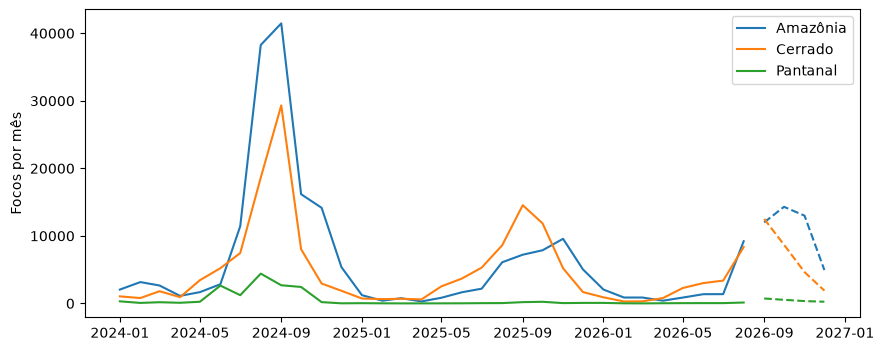

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

for bioma, grupo in monthly[monthly["mes"] >= "2024-01-01"].groupby("bioma"):
    linha, = ax.plot(grupo["mes"], grupo["focos"], label=bioma)
    prev = previsao[previsao["bioma"] == bioma]
    ax.plot(prev["mes"], prev["focos_previsto"], linestyle="--", color=linha.get_color())

ax.set_ylabel("Focos por mês")
ax.legend()

## Quanto confiar nessa previsão?

In [17]:
corte = pd.Timestamp("2025-08-01")
treino = df[df["mes"] <= corte]

modelo_teste = models.train_lgbm(treino, features=models.FEATURES)
normais_teste = models.climate_normals(clima[clima["mes"] <= corte])
prev_teste = models.forecast_future(
    monthly[monthly["mes"] <= corte], modelo_teste, normais_teste, n_months=4
)

In [19]:
real = monthly[(monthly["mes"] > corte) & (monthly["mes"] <= "2025-12-01")]
comparacao = prev_teste.merge(real, on=["bioma", "mes"])
comparacao["erro_abs"] = (comparacao["focos_previsto"] - comparacao["focos"]).abs()
comparacao.groupby("bioma")[["focos", "focos_previsto", "erro_abs"]].mean().round(0)

,focos,focos_previsto,erro_abs
bioma,,,
Amazônia,7421.0,16437.0,9015.0
Cerrado,8322.0,7756.0,1179.0
Pantanal,138.0,141.0,162.0


In [20]:
ano_anterior = monthly.copy()
ano_anterior["mes"] = ano_anterior["mes"] + pd.DateOffset(years=1)
ano_anterior = ano_anterior.rename(columns={"focos": "focos_ano_anterior"})

comparacao = comparacao.merge(ano_anterior, on=["bioma", "mes"])
comparacao["erro_baseline"] = (comparacao["focos_ano_anterior"] - comparacao["focos"]).abs()
comparacao.groupby("bioma")[["erro_abs", "erro_baseline"]].mean().round(0)

,erro_abs,erro_baseline
bioma,,
Amazônia,9015.0,11868.0
Cerrado,1179.0,5264.0
Pantanal,162.0,1225.0


In [21]:
monthly.to_csv("../data/processed/focos_mensais_atualizado.csv", index=False)
previsao.to_csv("../data/processed/previsao.csv", index=False)

## Conclusões desta etapa

- **Previsão para set–dez/2026:** aproximadamente 44 mil focos na Amazônia (pico em outubro), 28 mil no Cerrado (pico em setembro) e 1,9 mil no Pantanal, usando dados observados até agosto de 2026.
- **Método:** o modelo LightGBM foi treinado com toda a série até agosto de 2026. Como o clima futuro não é conhecido, foi usada a média histórica de cada mês; cada previsão alimenta a seguinte (previsão recursiva), então o erro tende a crescer ao longo dos meses.
- **Confiabilidade:** numa checagem retroativa (previsão feita em agosto de 2025 para set–dez/2025), o modelo errou menos que a regra "igual ao ano anterior" nos três biomas, mas superestimou a Amazônia em mais que o dobro. A previsão do Cerrado é a mais confiável; a da Amazônia deve ser lida como um cenário, não como valor esperado.
- **Limitações:** a checagem cobre uma única janela de 4 meses; o clima futuro é uma média histórica e não uma previsão meteorológica; eventos extremos como o de 2024 continuam difíceis de antecipar.